# ✈️ Airline Passenger Satisfaction Prediction

## 02. Exploratory Data Analysis

This notebook explores passenger characteristics, service ratings, travel information, delays, and their relationship with airline passenger satisfaction.

In [1]:
# Step 1 : Importing Libraries and Loading the Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_path = "../data/raw/train.csv"
test_path = "../data/raw/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

Training Dataset Shape: (103904, 25)
Testing Dataset Shape: (25976, 25)


In [2]:
# Step 2 : Basic Dataset Overview

print("Training Dataset Information:")
print(train_df.info())

print("\nFirst 5 Rows:")
display(train_df.head())

Training Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location       

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [3]:
# Step 3 : Statistical Summary

train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,51951.500000,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Age,103904.0,39.379706,15.114964,7.0,27.00,40.0,51.00,85.0
Flight Distance,103904.0,1189.448375,997.147281,31.0,414.00,843.0,1743.00,4983.0
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.00,3.0,4.00,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.00,3.0,4.00,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.00,3.0,4.00,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.00,3.0,4.00,5.0


In [4]:
# Step 4 : Identifying Feature Groups

target_column = "satisfaction"

categorical_features = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]

identifier_columns = [
    "Unnamed: 0",
    "id"
]

numerical_features = [
    column
    for column in train_df.select_dtypes(include=np.number).columns
    if column not in identifier_columns
]

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

print("\nTarget Variable:")
print(target_column)

Categorical Features:
['Gender', 'Customer Type', 'Type of Travel', 'Class']

Numerical Features:
['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Target Variable:
satisfaction


In [5]:
# Step 5 : Missing Value Analysis

missing_values = train_df.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

missing_values

Arrival Delay in Minutes    310
dtype: int64

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64


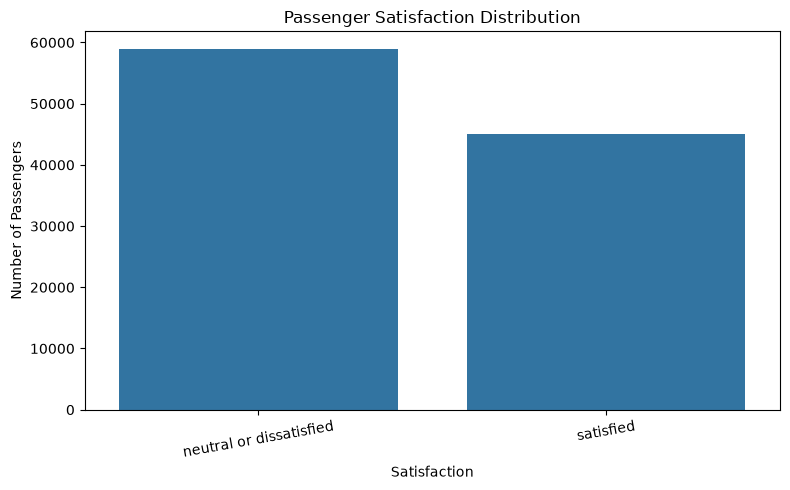

In [6]:
# Step 6 : Target Variable Distribution

target_counts = train_df[target_column].value_counts()

print(target_counts)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_df,
    x=target_column
)

plt.title("Passenger Satisfaction Distribution")
plt.xlabel("Satisfaction")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

satisfaction
neutral or dissatisfied    56.67
satisfied                  43.33
Name: proportion, dtype: float64


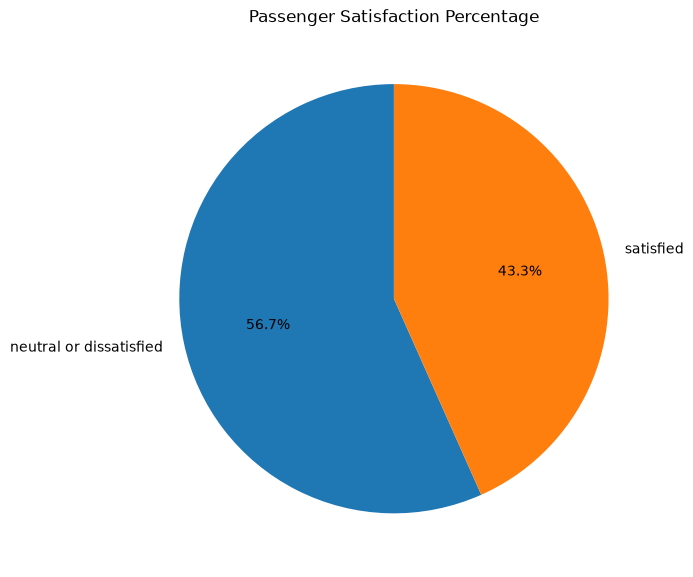

In [7]:
# Step 7 : Target Distribution Percentage

target_percentage = (
    train_df[target_column]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(target_percentage)

plt.figure(figsize=(7, 7))

plt.pie(
    target_percentage.values,
    labels=target_percentage.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Passenger Satisfaction Percentage")

plt.tight_layout()
plt.show()

   Gender  Satisfaction Rate
0  Female              42.74
1    Male              43.95


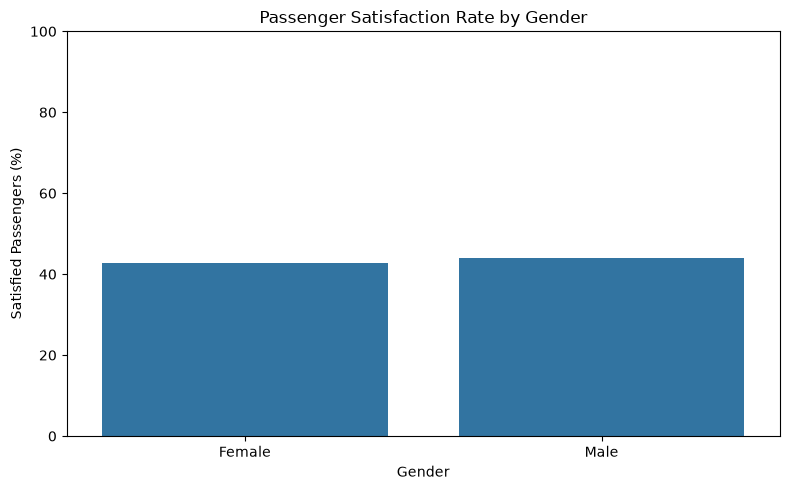

In [11]:
# Step 8 : Satisfaction Rate by Gender

gender_satisfaction = (
    train_df.groupby("Gender")[target_column]
    .apply(lambda x: (x == "satisfied").mean() * 100)
    .reset_index(name="Satisfaction Rate")
)

print(gender_satisfaction.round(2))

plt.figure(figsize=(8, 5))

sns.barplot(
    data=gender_satisfaction,
    x="Gender",
    y="Satisfaction Rate"
)

plt.title("Passenger Satisfaction Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Satisfied Passengers (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

       Customer Type  Satisfaction Rate
0     Loyal Customer              47.73
1  disloyal Customer              23.67


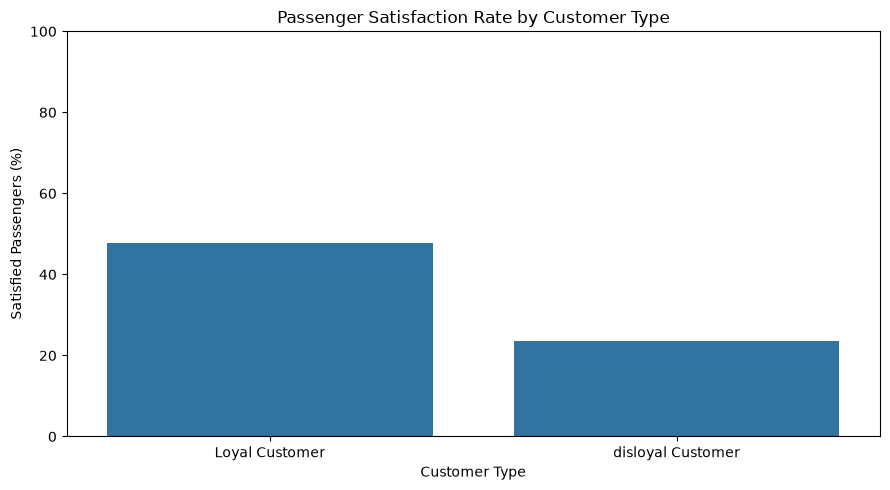

In [12]:
# Step 9 : Satisfaction Rate by Customer Type

customer_satisfaction = (
    train_df.groupby("Customer Type")[target_column]
    .apply(lambda x: (x == "satisfied").mean() * 100)
    .reset_index(name="Satisfaction Rate")
)

print(customer_satisfaction.round(2))

plt.figure(figsize=(9, 5))

sns.barplot(
    data=customer_satisfaction,
    x="Customer Type",
    y="Satisfaction Rate"
)

plt.title("Passenger Satisfaction Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Satisfied Passengers (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

    Type of Travel  Satisfaction Rate
0  Business travel              58.26
1  Personal Travel              10.17


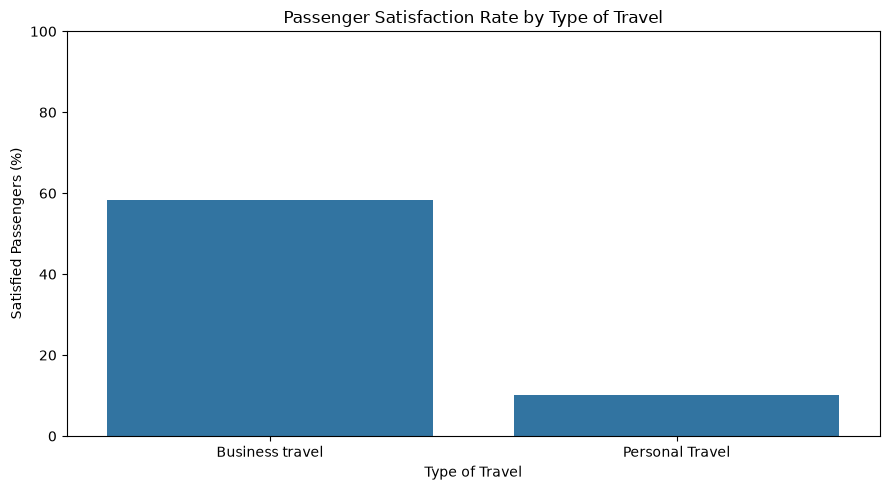

In [14]:
# Step 10 : Satisfaction Rate by Type of Travel

travel_satisfaction = (
    train_df.groupby("Type of Travel")[target_column]
    .apply(lambda x: (x == "satisfied").mean() * 100)
    .reset_index(name="Satisfaction Rate")
)

print(travel_satisfaction.round(2))

plt.figure(figsize=(9, 5))

sns.barplot(
    data=travel_satisfaction,
    x="Type of Travel",
    y="Satisfaction Rate"
)

plt.title("Passenger Satisfaction Rate by Type of Travel")
plt.xlabel("Type of Travel")
plt.ylabel("Satisfied Passengers (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

      Class  Satisfaction Rate
0  Business              69.43
1       Eco              18.61
2  Eco Plus              24.61


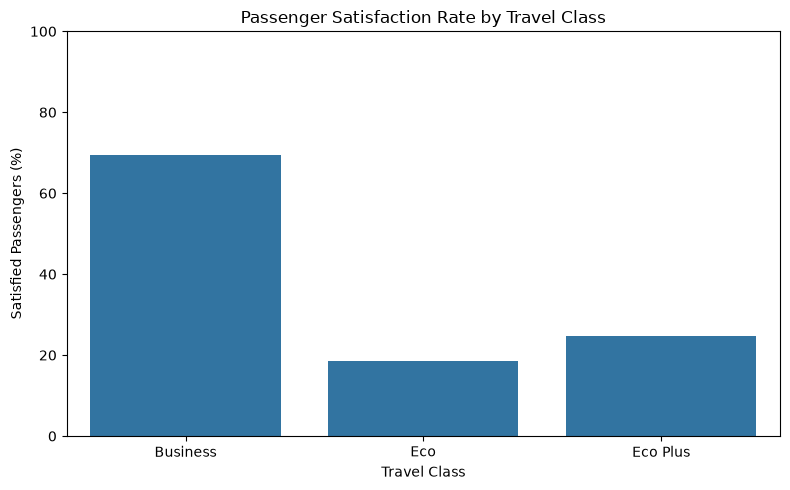

In [15]:
# Step 11 : Satisfaction Rate by Travel Class

class_satisfaction = (
    train_df.groupby("Class")[target_column]
    .apply(lambda x: (x == "satisfied").mean() * 100)
    .reset_index(name="Satisfaction Rate")
)

print(class_satisfaction.round(2))

plt.figure(figsize=(8, 5))

sns.barplot(
    data=class_satisfaction,
    x="Class",
    y="Satisfaction Rate"
)

plt.title("Passenger Satisfaction Rate by Travel Class")
plt.xlabel("Travel Class")
plt.ylabel("Satisfied Passengers (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

Inflight wifi service                2.73
Ease of Online booking               2.76
Gate location                        2.98
Departure/Arrival time convenient    3.06
Food and drink                       3.20
Online boarding                      3.25
Cleanliness                          3.29
Checkin service                      3.30
Leg room service                     3.35
Inflight entertainment               3.36
On-board service                     3.38
Seat comfort                         3.44
Baggage handling                     3.63
Inflight service                     3.64
dtype: float64


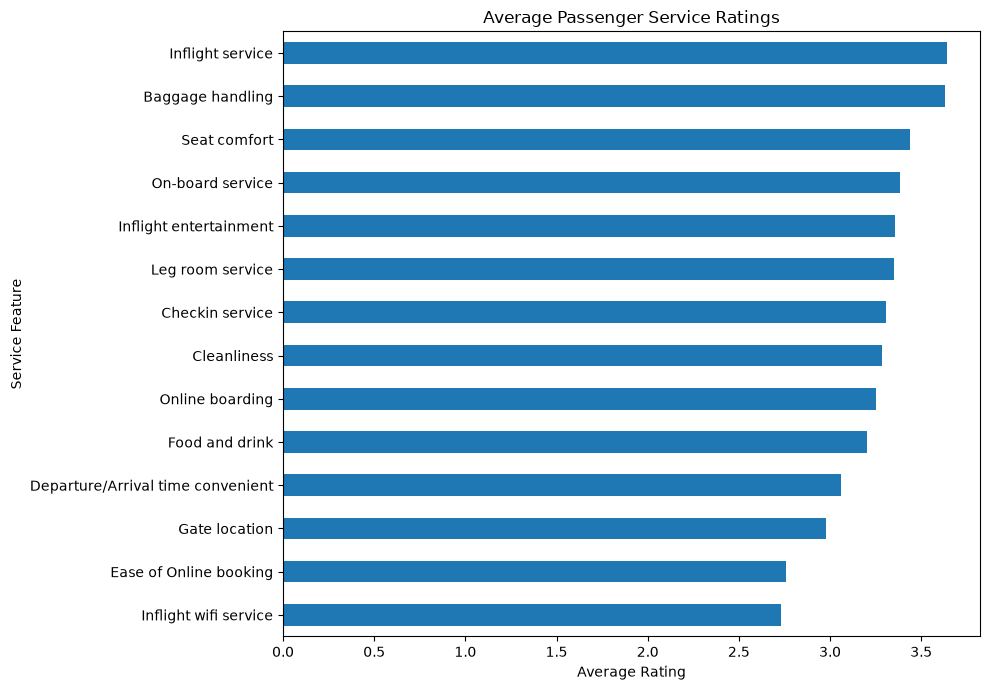

In [16]:
# Step 12 : Average Service Ratings

service_features = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

service_means = (
    train_df[service_features]
    .mean()
    .sort_values(ascending=True)
)

print(service_means.round(2))

plt.figure(figsize=(10, 7))

service_means.plot(kind="barh")

plt.title("Average Passenger Service Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Service Feature")

plt.tight_layout()
plt.show()

satisfaction                       neutral or dissatisfied  satisfied
Inflight wifi service                                 2.40       3.16
Departure/Arrival time convenient                     3.13       2.97
Ease of Online booking                                2.55       3.03
Gate location                                         2.98       2.98
Food and drink                                        2.96       3.52
Online boarding                                       2.66       4.03
Seat comfort                                          3.04       3.97
Inflight entertainment                                2.89       3.96
On-board service                                      3.02       3.86
Leg room service                                      2.99       3.82
Baggage handling                                      3.38       3.97
Checkin service                                       3.04       3.65
Inflight service                                      3.39       3.97
Cleanliness         

<Figure size 1100x800 with 0 Axes>

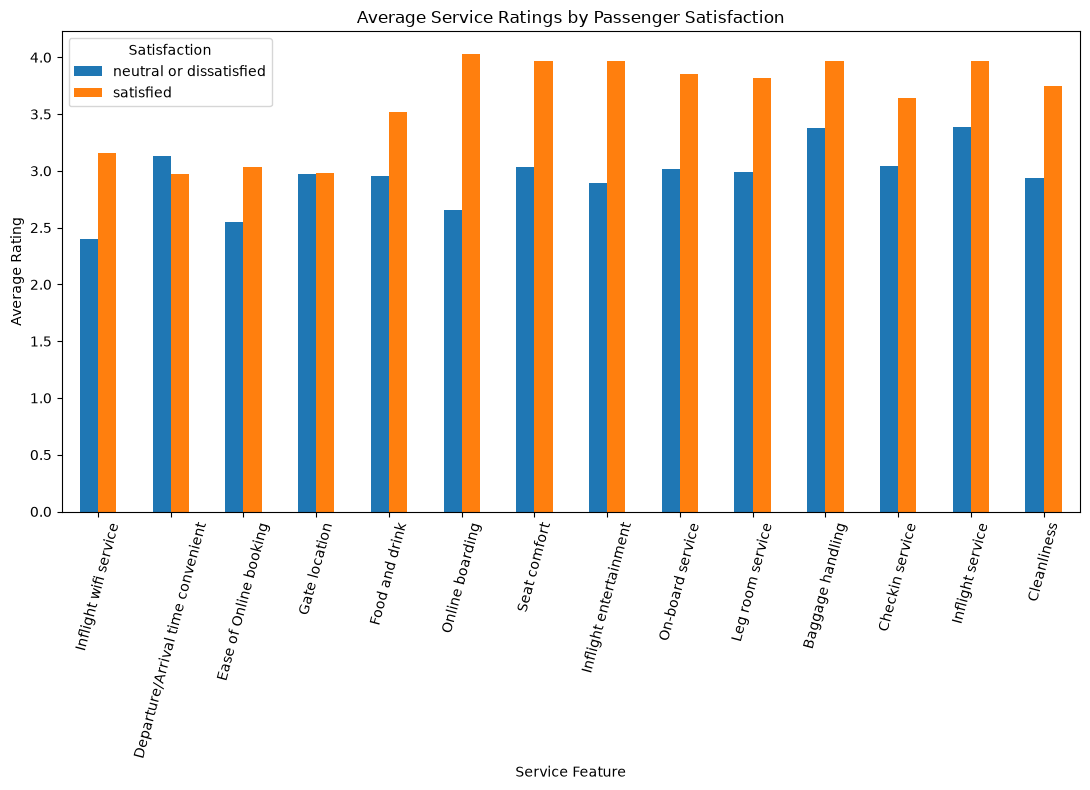

In [17]:
# Step 13 : Service Ratings by Satisfaction

service_by_satisfaction = (
    train_df
    .groupby(target_column)[service_features]
    .mean()
    .T
)

print(service_by_satisfaction.round(2))

plt.figure(figsize=(11, 8))

service_by_satisfaction.plot(
    kind="bar",
    figsize=(11, 8)
)

plt.title("Average Service Ratings by Passenger Satisfaction")
plt.xlabel("Service Feature")
plt.ylabel("Average Rating")
plt.xticks(rotation=75)

plt.legend(title="Satisfaction")

plt.tight_layout()
plt.show()

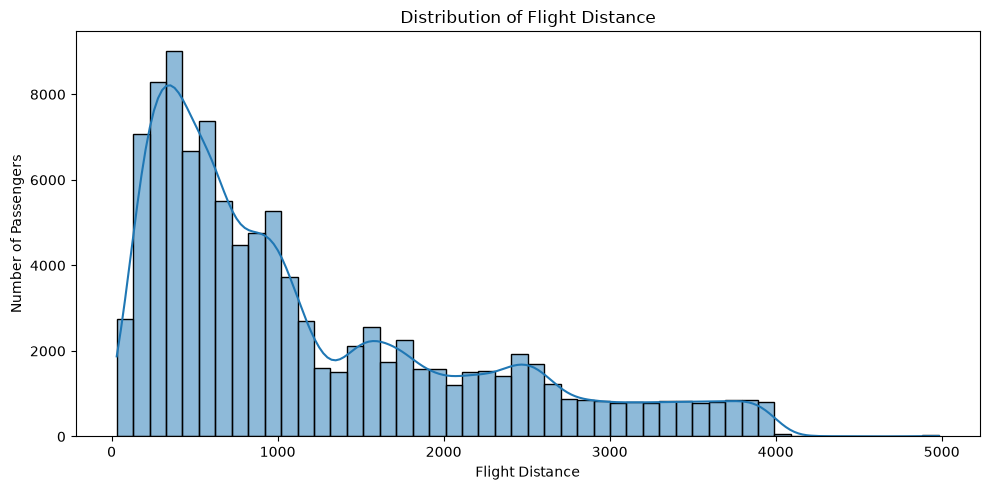

In [18]:
# Step 14 : Flight Distance Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=train_df,
    x="Flight Distance",
    bins=50,
    kde=True
)

plt.title("Distribution of Flight Distance")
plt.xlabel("Flight Distance")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

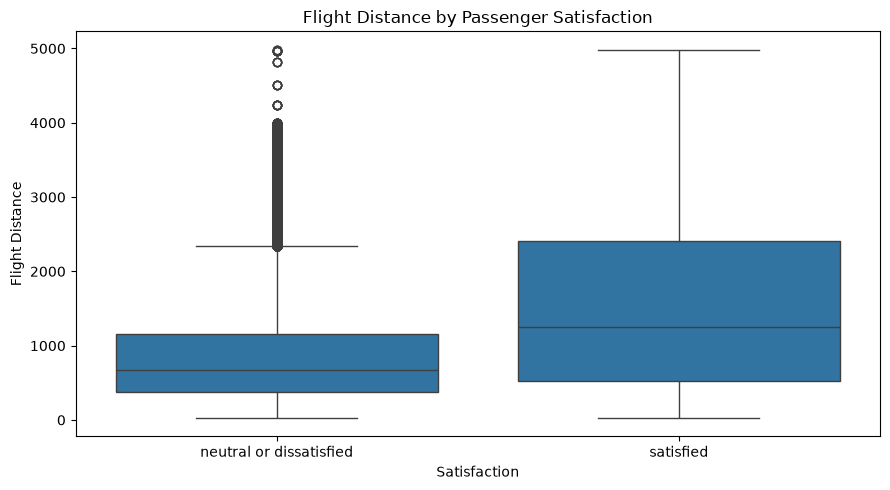

In [19]:
# Step 15 : Flight Distance by Satisfaction

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=train_df,
    x=target_column,
    y="Flight Distance"
)

plt.title("Flight Distance by Passenger Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Flight Distance")

plt.tight_layout()
plt.show()

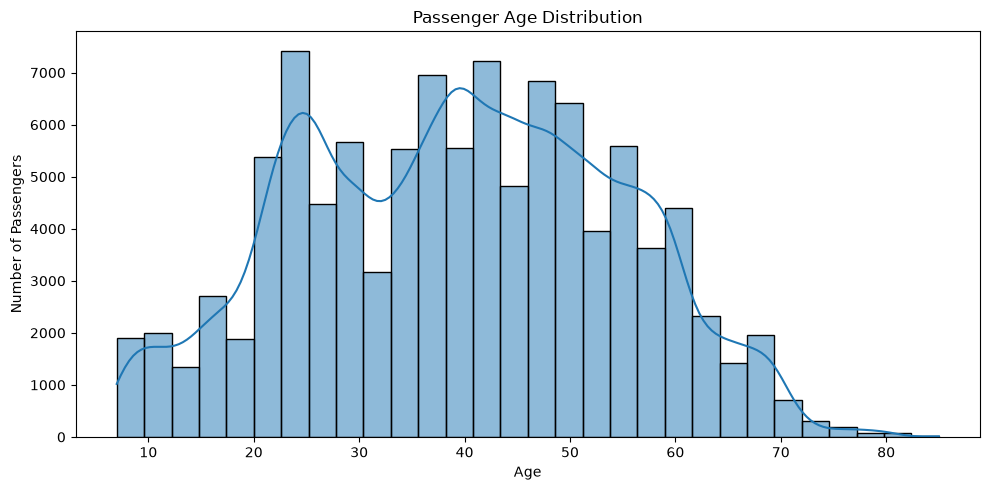

In [20]:
# Step 16 : Passenger Age Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=train_df,
    x="Age",
    bins=30,
    kde=True
)

plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

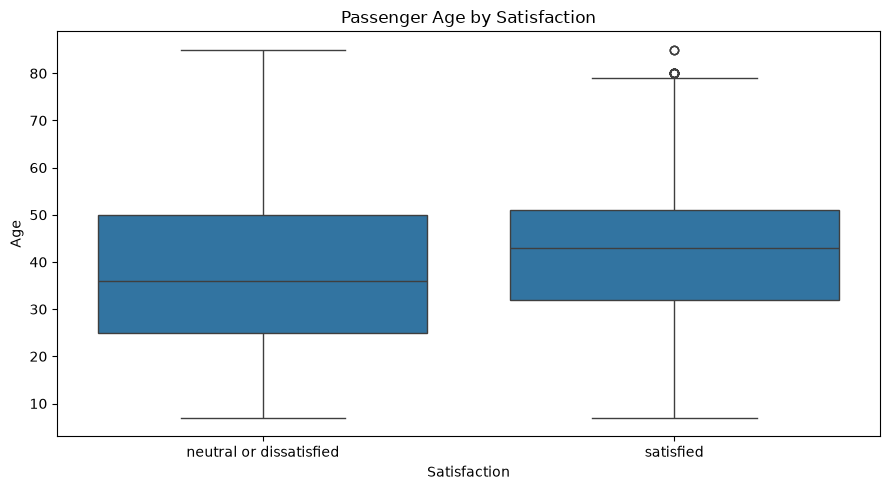

In [21]:
# Step 17 : Passenger Age by Satisfaction

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=train_df,
    x=target_column,
    y="Age"
)

plt.title("Passenger Age by Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

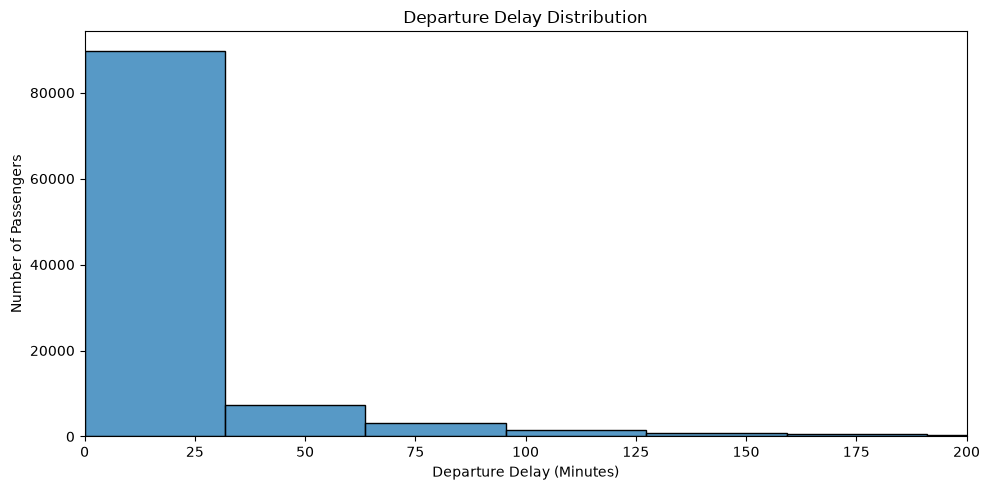

In [22]:
# Step 18 : Departure Delay Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=train_df,
    x="Departure Delay in Minutes",
    bins=50
)

plt.xlim(0, 200)

plt.title("Departure Delay Distribution")
plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

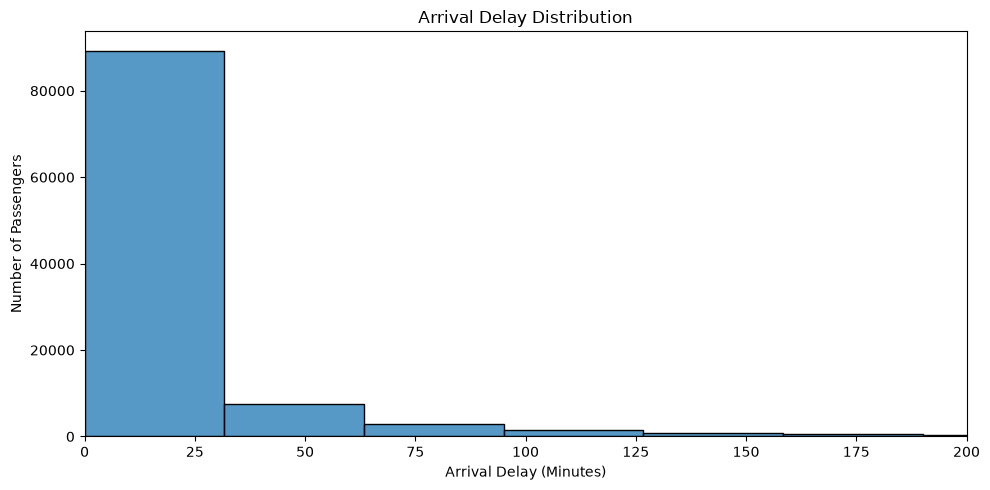

In [23]:
# Step 19 : Arrival Delay Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=train_df,
    x="Arrival Delay in Minutes",
    bins=50
)

plt.xlim(0, 200)

plt.title("Arrival Delay Distribution")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

                         Departure Delay in Minutes  Arrival Delay in Minutes
satisfaction                                                                 
neutral or dissatisfied                       16.50                     17.13
satisfied                                     12.61                     12.63


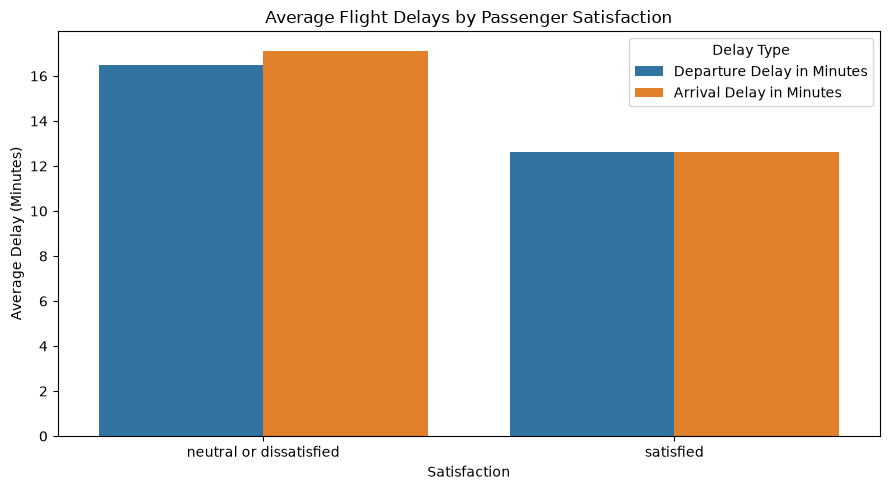

In [24]:
# Step 20 : Average Delays by Satisfaction

delay_features = [
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

delay_by_satisfaction = (
    train_df
    .groupby(target_column)[delay_features]
    .mean()
)

print(delay_by_satisfaction.round(2))

delay_plot_data = (
    delay_by_satisfaction
    .reset_index()
    .melt(
        id_vars=target_column,
        var_name="Delay Type",
        value_name="Average Delay"
    )
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=delay_plot_data,
    x=target_column,
    y="Average Delay",
    hue="Delay Type"
)

plt.title("Average Flight Delays by Passenger Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Average Delay (Minutes)")

plt.tight_layout()
plt.show()

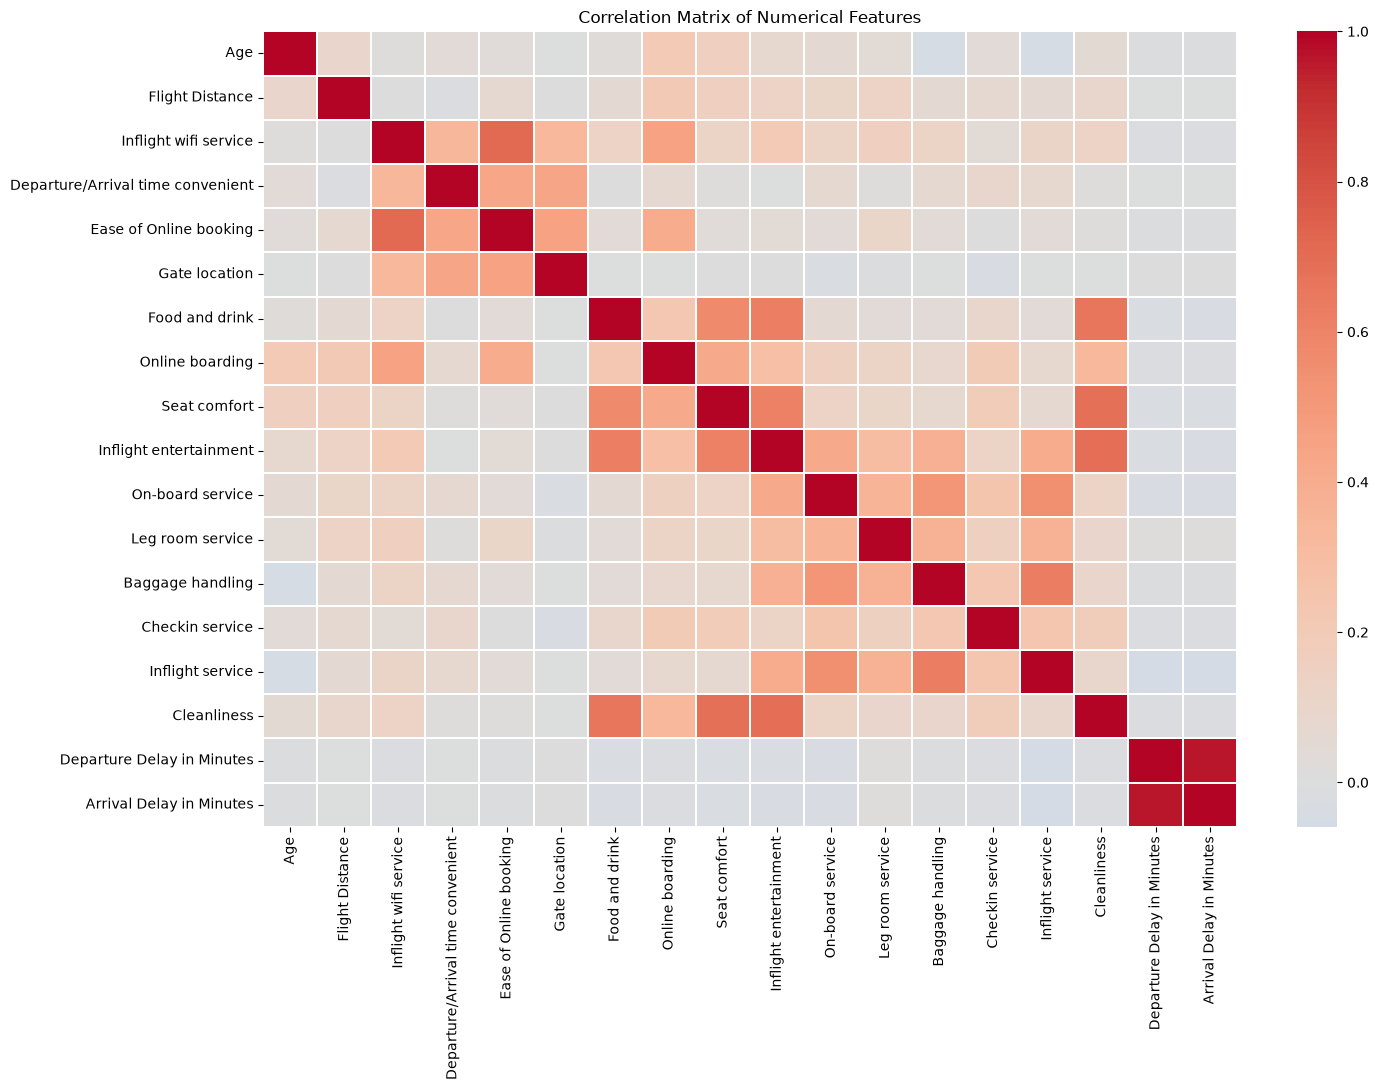

In [25]:
# Step 21 : Numerical Feature Correlation

correlation_matrix = train_df[numerical_features].corr()

plt.figure(figsize=(15, 11))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

Arrival Delay in Minutes            -0.058
Departure/Arrival time convenient   -0.052
Departure Delay in Minutes          -0.050
Gate location                        0.001
Age                                  0.137
Ease of Online booking               0.172
Food and drink                       0.210
Checkin service                      0.236
Inflight service                     0.245
Baggage handling                     0.248
Inflight wifi service                0.284
Flight Distance                      0.299
Cleanliness                          0.305
Leg room service                     0.313
On-board service                     0.322
Seat comfort                         0.349
Inflight entertainment               0.398
Online boarding                      0.504
dtype: float64


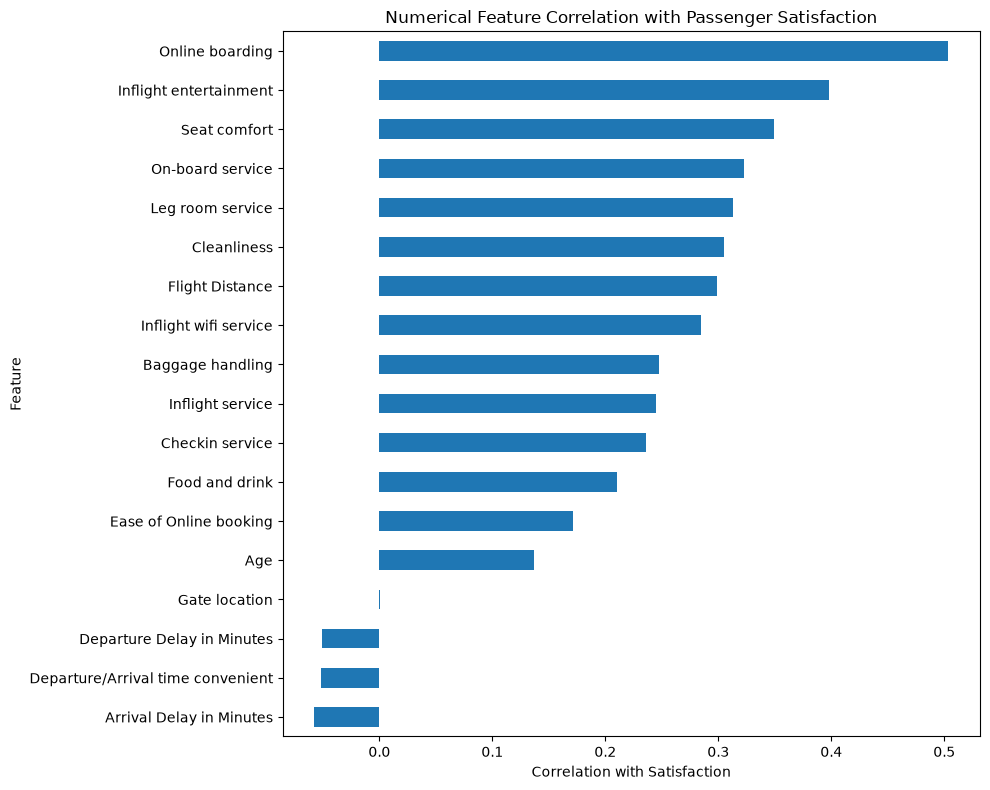

In [26]:
# Step 22 : Numerical Feature Correlation with Satisfaction

target_numeric = train_df[target_column].map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})

target_correlation = (
    train_df[numerical_features]
    .corrwith(target_numeric)
    .sort_values()
)

print(target_correlation.round(3))

plt.figure(figsize=(10, 8))

target_correlation.plot(kind="barh")

plt.title("Numerical Feature Correlation with Passenger Satisfaction")
plt.xlabel("Correlation with Satisfaction")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Departure/Arrival time convenient   -0.16
Gate location                        0.00
Ease of Online booking               0.48
Food and drink                       0.56
Inflight service                     0.58
Baggage handling                     0.59
Checkin service                      0.60
Inflight wifi service                0.76
Cleanliness                          0.81
Leg room service                     0.83
On-board service                     0.84
Seat comfort                         0.93
Inflight entertainment               1.07
Online boarding                      1.37
dtype: float64


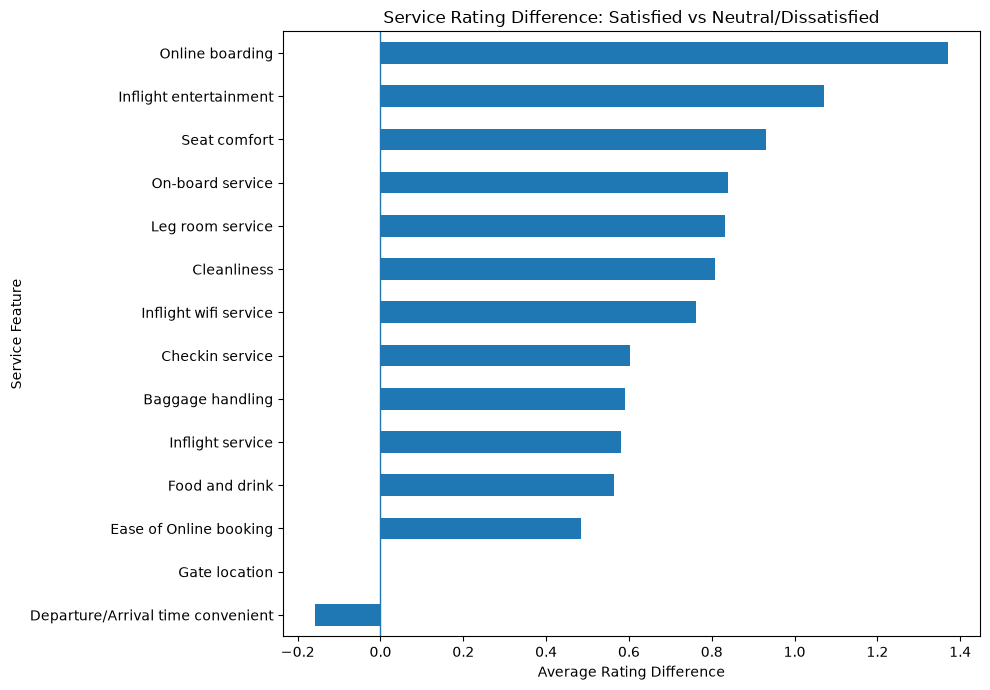

In [27]:
# Step 23 : Service Features with Largest Satisfaction Gap

satisfaction_service_means = (
    train_df
    .groupby(target_column)[service_features]
    .mean()
)

service_difference = (
    satisfaction_service_means.loc["satisfied"]
    - satisfaction_service_means.loc["neutral or dissatisfied"]
)

service_difference = service_difference.sort_values(
    ascending=True
)

print(service_difference.round(2))

plt.figure(figsize=(10, 7))

service_difference.plot(kind="barh")

plt.title(
    "Service Rating Difference: Satisfied vs Neutral/Dissatisfied"
)

plt.xlabel(
    "Average Rating Difference"
)

plt.ylabel("Service Feature")

plt.axvline(
    x=0,
    linewidth=1
)

plt.tight_layout()
plt.show()

      Class   Type of Travel  Satisfaction Rate
0  Business  Business travel              72.02
1  Business  Personal Travel              12.24
2       Eco  Business travel              29.62
3       Eco  Personal Travel              10.20
4  Eco Plus  Business travel              39.33
5  Eco Plus  Personal Travel               8.71


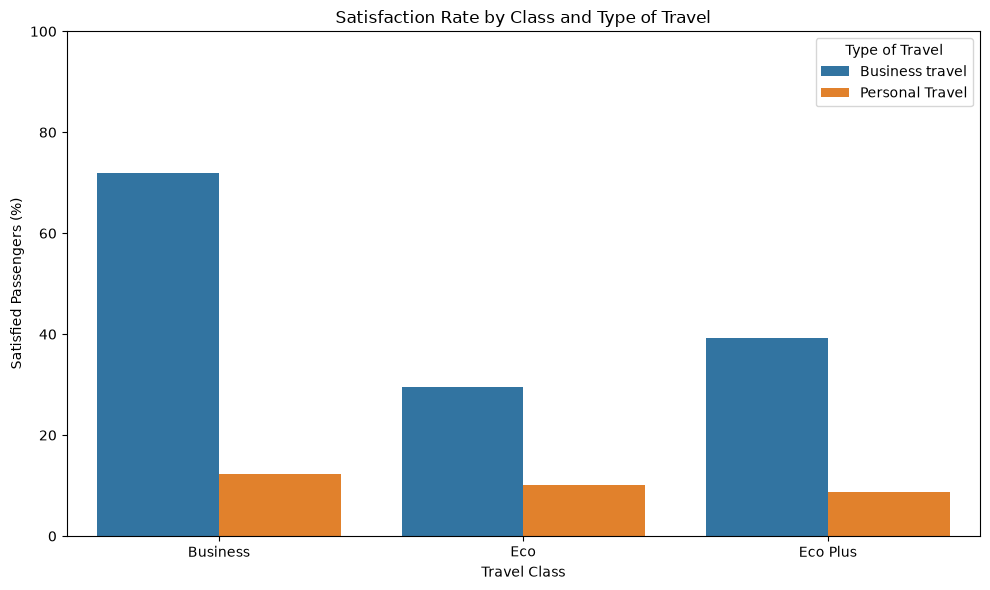

In [28]:
# Step 24 : Satisfaction by Class and Type of Travel

class_travel_satisfaction = (
    train_df
    .groupby(["Class", "Type of Travel"])[target_column]
    .apply(lambda x: (x == "satisfied").mean() * 100)
    .reset_index(name="Satisfaction Rate")
)

print(class_travel_satisfaction.round(2))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=class_travel_satisfaction,
    x="Class",
    y="Satisfaction Rate",
    hue="Type of Travel"
)

plt.title("Satisfaction Rate by Class and Type of Travel")
plt.xlabel("Travel Class")
plt.ylabel("Satisfied Passengers (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

       Customer Type   Type of Travel  Satisfaction Rate
0     Loyal Customer  Business travel              70.56
1     Loyal Customer  Personal Travel              10.14
2  disloyal Customer  Business travel              23.73
3  disloyal Customer  Personal Travel              15.85


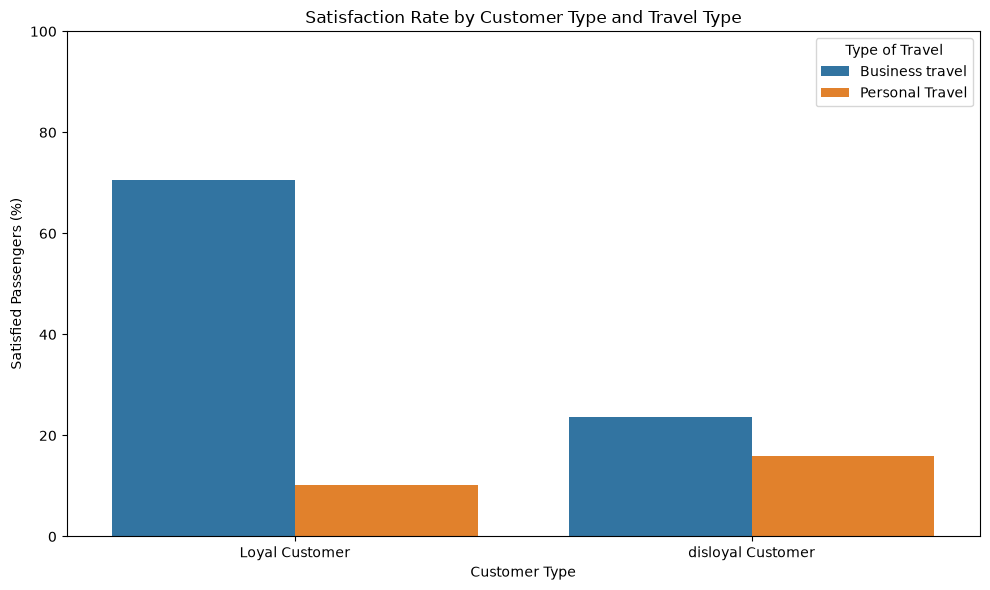

In [29]:
# Step 25 : Satisfaction by Customer Type and Travel Type

customer_travel_satisfaction = (
    train_df
    .groupby(["Customer Type", "Type of Travel"])[target_column]
    .apply(lambda x: (x == "satisfied").mean() * 100)
    .reset_index(name="Satisfaction Rate")
)

print(customer_travel_satisfaction.round(2))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=customer_travel_satisfaction,
    x="Customer Type",
    y="Satisfaction Rate",
    hue="Type of Travel"
)

plt.title("Satisfaction Rate by Customer Type and Travel Type")
plt.xlabel("Customer Type")
plt.ylabel("Satisfied Passengers (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [30]:
# Step 26 : Key EDA Statistics

eda_summary = pd.DataFrame({
    "Metric": [
        "Total Training Passengers",
        "Total Testing Passengers",
        "Satisfied Passengers",
        "Neutral/Dissatisfied Passengers",
        "Missing Arrival Delay Values",
        "Duplicate Training Rows",
        "Duplicate Testing Rows",
        "Average Passenger Age",
        "Average Flight Distance",
        "Average Departure Delay",
        "Average Arrival Delay"
    ],
    "Value": [
        len(train_df),
        len(test_df),
        (train_df[target_column] == "satisfied").sum(),
        (train_df[target_column] == "neutral or dissatisfied").sum(),
        train_df["Arrival Delay in Minutes"].isnull().sum(),
        train_df.duplicated().sum(),
        test_df.duplicated().sum(),
        round(train_df["Age"].mean(), 2),
        round(train_df["Flight Distance"].mean(), 2),
        round(train_df["Departure Delay in Minutes"].mean(), 2),
        round(train_df["Arrival Delay in Minutes"].mean(), 2)
    ]
})

eda_summary

,Metric,Value
0,Total Training Passengers,103904.00
1,Total Testing Passengers,25976.00
2,Satisfied Passengers,45025.00
3,Neutral/Dissatisfied Passengers,58879.00
4,Missing Arrival Delay Values,310.00
5,Duplicate Training Rows,0.00
6,Duplicate Testing Rows,0.00
7,Average Passenger Age,39.38
8,Average Flight Distance,1189.45
9,Average Departure Delay,14.82


# 🔎 Key EDA Findings

### Key Findings

- The dataset contains a large number of airline passenger records with a binary satisfaction target.
- Passenger satisfaction varies across customer type, travel purpose, and travel class.
- Gender shows comparatively smaller differences in satisfaction than several service-related variables.
- Service ratings show noticeable differences between satisfied and neutral/dissatisfied passengers.
- Online boarding, inflight services, entertainment, seat comfort, and other service-quality variables provide useful signals for satisfaction prediction.
- Business and personal travelers show different satisfaction patterns.
- Satisfaction also varies across Business, Eco, and Eco Plus travel classes.
- Loyal and disloyal customers exhibit different satisfaction behavior.
- Flight distance varies considerably across passengers.
- Departure and arrival delays are strongly right-skewed, with some extreme delay observations.
- `Arrival Delay in Minutes` contains a small number of missing values and will require preprocessing.
- `Unnamed: 0` and `id` are identifier columns and should not be used as predictive features.
- Numerical features exist on different scales, making feature scaling important for the ANN model.
- Overall, the EDA indicates that passenger satisfaction can be modeled as a binary classification problem using an Artificial Neural Network.